# Блок 4. A/B-тест: дизайн и симуляция

**Бизнес-гипотеза:** персональная скидка 15% для сегмента At Risk
повышает retention в следующем месяце.

**Природа блока:** реальный A/B на исторических данных невозможен.
Демонстрируется:
1. Методология планирования эксперимента (на реальном baseline retention)
2. Процедура статистического анализа (на симулированном эффекте)

**Метрика:** retention M+1 — бинарная (вернулся / не вернулся)
**Параметры:** α = 0.05, мощность = 0.8, MDE = 3 п.п.

## 0. Подготовка: импорты и подключение к ClickHouse

In [119]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep, proportion_effectsize
from sklearn.model_selection import train_test_split

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    username='analyst', password='analyst', database='hm'
)
def q(sql): return client.query_df(sql)

## 1. Baseline retention сегмента At Risk

Чтобы спланировать эксперимент, нужно знать отправную точку — какой retention
у сегмента At Risk **без** какого-либо воздействия. Это retention будущей
контрольной группы (A).

**Защита от data leakage.** Сегмент и его retention считаются на
непересекающихся периодах:
- *Определение сегмента* — окно 2019-08 … 2020-07 (по нему считаем R и F)
- *Измерение возврата* — август 2020 (следующий месяц, не входит в определение)

Это исключает утечку: мы не используем поведение клиента в августе для того,
чтобы его же августом и измерять. Сегмент At Risk выделяется заново по той же
RF-логике, что в основной RFM-витрине, но на сдвинутом окне.

In [120]:
ab_base = q("""
WITH
-- R и F по периоду определения (год, заканчивается июлем 2020)
rfm_base AS (
    SELECT
        customer_id,
        dateDiff('day', max(t_dat), toDate('2020-07-31')) AS recency,
        count() AS frequency
    FROM hm.transactions
    WHERE t_dat BETWEEN '2019-08-01' AND '2020-07-31'
    GROUP BY customer_id
),
-- Квинтили R и F
rfm_scored AS (
    SELECT
        customer_id,
        ntile(5) OVER (ORDER BY recency DESC)  AS r_score,
        ntile(5) OVER (ORDER BY frequency ASC) AS f_score
    FROM rfm_base
),
-- Только At Risk (та же логика что в основной витрине: низкий R, высокий F)
at_risk AS (
    SELECT customer_id, r_score, f_score
    FROM rfm_scored
    WHERE (r_score <= 2 AND f_score >= 4)
       OR (r_score = 2 AND f_score = 3)
       OR (r_score = 3 AND f_score = 3)
),
-- Кто из них купил в августе 2020 (период измерения)
returned_aug AS (
    SELECT DISTINCT customer_id
    FROM hm.transactions
    WHERE t_dat BETWEEN '2020-08-01' AND '2020-08-31'
)
SELECT
    ar.customer_id,
    ar.r_score,
    ar.f_score,
    if(ra.customer_id != '', 1, 0) AS returned
FROM at_risk ar
LEFT JOIN returned_aug ra ON ar.customer_id = ra.customer_id
""")

print(f"At Risk клиентов: {len(ab_base):,}")
print(f"Вернулись в августе: {ab_base['returned'].sum():,}")
print(f"Baseline retention: {ab_base['returned'].mean()*100:.2f}%")
ab_base.head()

At Risk клиентов: 158,544
Вернулись в августе: 27,038
Baseline retention: 17.05%


,customer_id,r_score,f_score,returned
0,b'6476ca0c10b019c0a7343a72b9cf5b9e0341ac42f1b9...,1,4,0
1,b'f7f6699cda2a6b605b2665025906cac2ea7699754924...,1,4,0
2,b'b3854e49ef32970c8b661d5345a3f3050a1f5317c7d6...,1,4,1
3,b'b6b949c9ee7a2bc94aa79ef7869049a70059bf31f472...,1,4,0
4,b'80d0cc96bf3933b7c15360c03b6be7db3feeb86e6a48...,1,4,0


**Baseline retention сегмента At Risk:**
- 158 539 клиентов в сегменте (определён по окну 2019-08 .. 2020-07).
- 27 038 вернулись за покупкой в августе 2020.
- Baseline retention M+1 = **17.05%**.

Периоды определения сегмента (по июль) и измерения возврата (август)
не пересекаются — нет data leakage. Это retention контрольной группы (A),
от него считаем требуемый эффект скидки.

## 2. Расчёт размера выборки

Прежде чем запускать тест, определяем сколько клиентов нужно в каждой группе,
чтобы надёжно засечь целевой эффект.

**Параметры дизайна:**
- Baseline (группа A): 17%
- MDE (минимальный детектируемый эффект): 3 п.п. → целевой retention B = 20%
- Уровень значимости α = 0.05 (риск ложноположительного вывода)
- Мощность = 0.80 (вероятность заметить эффект, если он есть)

Размер выборки обратно пропорционален квадрату MDE: чем меньший эффект хотим
уловить, тем больше выборка. Расчёт выполняем через `statsmodels`.

In [ ]:
baseline = ab_base['returned'].mean()   
mde_pp = 0.03                            
p_control = baseline                     # ожидаемый retention в группе A
p_treatment = baseline + mde_pp          # ожидаемый retention в группе B (если скидка сработает)

alpha = 0.05                             # риск ошибки I рода
power = 0.80                             # мощность (1 - риск ошибки II рода)

effect_size = proportion_effectsize(p_treatment, p_control)

analysis = NormalIndPower()
n_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1.0,            
    alternative='two-sided'
)

print(f"Baseline retention (A):     {p_control*100:.2f}%")
print(f"Целевой retention (B):      {p_treatment*100:.2f}%")
print(f"MDE:                        {mde_pp*100:.0f} п.п.")
print(f"Effect size (Cohen's h):    {effect_size:.4f}")
print(f"Нужно на группу:            {np.ceil(n_per_group):,.0f}")
print(f"Всего (A + B):              {np.ceil(n_per_group)*2:,.0f}")
print(f"\nДоступно At Risk клиентов:  {len(ab_base):,}")

Baseline retention (A):     17.05%
Целевой retention (B):      20.05%
MDE:                        3 п.п.
Effect size (Cohen's h):    0.0772
Нужно на группу:            2,632
Всего (A + B):              5,264

Доступно At Risk клиентов:  158,544


**Результат расчёта:**
При baseline 17%, MDE 3 п.п., α=0.05 и мощности 0.8 — достаточно
**2 632 клиента в каждой группе** (5 264 всего).

В сегменте At Risk 158 539 клиентов — выборки хватает с большим запасом.
Это означает что тест реализуем: не нужно ждать накопления трафика,
данных достаточно уже сейчас.

Cohen's h = 0.077 — небольшой effect size, что типично для retention-метрик
в ритейле. Именно поэтому важно было посчитать выборку заранее: малый эффект
требует достаточного N, иначе тест просто не «увидит» реальный прирост.

## 3. Формирование групп A/B

Из 158K At Risk клиентов берём 6 000 (3 000 на группу) — с небольшим
запасом к расчётному минимуму. Это имитирует реальный тест, где размер
выборки ограничен расчётом.

Стратификация по комбинации r_score и f_score гарантирует что структура
страт в A и B совпадёт. После деления проводим A/A-проверку: retention
обеих групп до вмешательства должен быть близок — это подтверждает
что группы сопоставимы.

In [ ]:
n_per_group = 3000
n_total = n_per_group * 2   

ab_base['stratum'] = ab_base['r_score'].astype(str) + '_' + ab_base['f_score'].astype(str)

ab_sample, _ = train_test_split(
    ab_base,
    train_size=n_total,
    stratify=ab_base['stratum'],
    random_state=42
)

group_A, group_B = train_test_split(
    ab_sample,
    test_size=0.5,
    stratify=ab_sample['stratum'],
    random_state=42
)

group_A = group_A.copy(); group_A['group'] = 'A'
group_B = group_B.copy(); group_B['group'] = 'B'

print(f"Всего в тесте: {len(ab_sample):,} (расчётный минимум был 2632/группу)")
print(f"Группа A: {len(group_A):,}")
print(f"Группа B: {len(group_B):,}")

print(f"\nRetention A (до эффекта): {group_A['returned'].mean()*100:.2f}%")
print(f"Retention B (до эффекта): {group_B['returned'].mean()*100:.2f}%")

Всего в тесте: 6,000 (расчётный минимум был 2632/группу)
Группа A: 3,000
Группа B: 3,000

Retention A (до эффекта): 17.33%
Retention B (до эффекта): 16.77%


## 4. Симуляция эффекта скидки

Поскольку данные исторические, реальный эффект скидки наблюдать невозможно.
Мы искусственно вносим uplift +3 п.п. в группу B: часть клиенто

In [123]:
target_uplift = 0.03   

group_B_sim = group_B.copy()

# Сколько НЕ вернувшихся в B
non_returned_mask = group_B_sim['returned'] == 0
n_non_returned = non_returned_mask.sum()

# Сколько из них надо "конвертировать" чтобы получить +3 п.п. ко всей группе B
n_to_convert = int(round(target_uplift * len(group_B_sim)))

# Случайно выбираем кого конвертировать среди не вернувшихся
non_returned_idx = group_B_sim[non_returned_mask].index
convert_idx = np.random.choice(non_returned_idx, size=n_to_convert, replace=False)
group_B_sim.loc[convert_idx, 'returned'] = 1

print(f"Retention A:              {group_A['returned'].mean()*100:.2f}%")
print(f"Retention B (после скидки): {group_B_sim['returned'].mean()*100:.2f}%")
print(f"Наблюдаемый uplift:       {(group_B_sim['returned'].mean() - group_A['returned'].mean())*100:.2f} п.п.")

Retention A:              17.33%
Retention B (после скидки): 19.77%
Наблюдаемый uplift:       2.43 п.п.


## 5. Статистический тест

Проверяем: наблюдаемая разница между группами статистически значима
или могла возникнуть случайно?

Метрика бинарная (вернулся / нет) → применяем **z-тест для двух пропорций**.
Нулевая гипотеза H₀: retention A и B одинаков, разница случайна.
Решение принимается при α = 0.05.

In [ ]:
successes_A = group_A['returned'].sum()
successes_B = group_B_sim['returned'].sum()
n_A = len(group_A)
n_B = len(group_B_sim)

count = np.array([successes_B, successes_A])   # успехи: B, A
nobs  = np.array([n_B, n_A])                    # размеры: B, A

# z-тест для двух пропорций
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"Группа A: {successes_A:,} / {n_A:,} = {successes_A/n_A*100:.2f}%")
print(f"Группа B: {successes_B:,} / {n_B:,} = {successes_B/n_B*100:.2f}%")
print(f"Uplift:   {(successes_B/n_B - successes_A/n_A)*100:.2f} п.п.")
print(f"\nz-статистика: {z_stat:.4f}")
print(f"p-value:      {p_value:.5f}")

Группа A: 520 / 3,000 = 17.33%
Группа B: 593 / 3,000 = 19.77%
Uplift:   2.43 п.п.

z-статистика: 2.4245
p-value:      0.01533


Uplift 2.23 п.п. статистически значим (p < 0.05) — H₀ отвергается.
Эффект скидки обнаружен при заданных параметрах дизайна.

## 6. Доверительный интервал

p-value отвечает на вопрос «значим ли эффект», но не говорит насколько он велик
и насколько точно оценён. Доверительный интервал даёт диапазон правдоподобных
значений истинного uplift.

In [125]:
ci_low, ci_upp = confint_proportions_2indep(
    successes_B, n_B,
    successes_A, n_A,
    method='wald'
)

obs_uplift = successes_B/n_B - successes_A/n_A

print(f"Наблюдаемый uplift:    {obs_uplift*100:.2f} п.п.")
print(f"95% доверительный интервал: [{ci_low*100:.2f}; {ci_upp*100:.2f}] п.п.")
print(f"\nИнтерпретация: с вероятностью 95% истинный эффект скидки")
print(f"лежит между {ci_low*100:.2f} и {ci_upp*100:.2f} процентных пунктов.")

Наблюдаемый uplift:    2.43 п.п.
95% доверительный интервал: [0.47; 4.40] п.п.

Интерпретация: с вероятностью 95% истинный эффект скидки
лежит между 0.47 и 4.40 процентных пунктов.


Интервал не содержит ноль — согласуется с p < 0.05.
Нижняя граница интервала показывает минимальный эффект, на который
стоит рассчитывать при внедрении кампании.

## 7. Bootstrap-проверка

Дополнительно оцениваем устойчивость результата непараметрическим методом.
Выборка многократно (10 000 раз) пересобирается из самой себя с возвращением,
на каждой пересборке считается uplift. Распределение этих значений даёт
доверительный интервал напрямую из данных, без предположений о нормальности.

Если bootstrap-интервал согласуется с интервалом из z-теста — вывод
не зависит от выбранного метода.

In [126]:
n_iterations = 10000

returned_A = group_A['returned'].values
returned_B = group_B_sim['returned'].values

boot_uplifts = []
for _ in range(n_iterations):
    # Пересэмплируем каждую группу с возвращением
    sample_A = np.random.choice(returned_A, size=len(returned_A), replace=True)
    sample_B = np.random.choice(returned_B, size=len(returned_B), replace=True)
    boot_uplifts.append(sample_B.mean() - sample_A.mean())

boot_uplifts = np.array(boot_uplifts)

# Перцентильный доверительный интервал 95%
ci_low_boot = np.percentile(boot_uplifts, 2.5) * 100
ci_upp_boot = np.percentile(boot_uplifts, 97.5) * 100

print(f"Bootstrap uplift (среднее): {boot_uplifts.mean()*100:.2f} п.п.")
print(f"95% bootstrap CI:           [{ci_low_boot:.2f}; {ci_upp_boot:.2f}] п.п.")
print(f"Доля итераций с uplift > 0: {(boot_uplifts > 0).mean()*100:.1f}%")

Bootstrap uplift (среднее): 2.44 п.п.
95% bootstrap CI:           [0.47; 4.43] п.п.
Доля итераций с uplift > 0: 99.3%


**Результат:** среднее bootstrap-uplift 2.51 п.п., 95% CI [0.60; 4.43] п.п.
Интервал не содержит ноль, 99.4% итераций дают положительный uplift —
эффект устойчив. Bootstrap-интервал согласуется с параметрическим (z-тест),
что подтверждает надёжность вывода двумя независимыми методами.

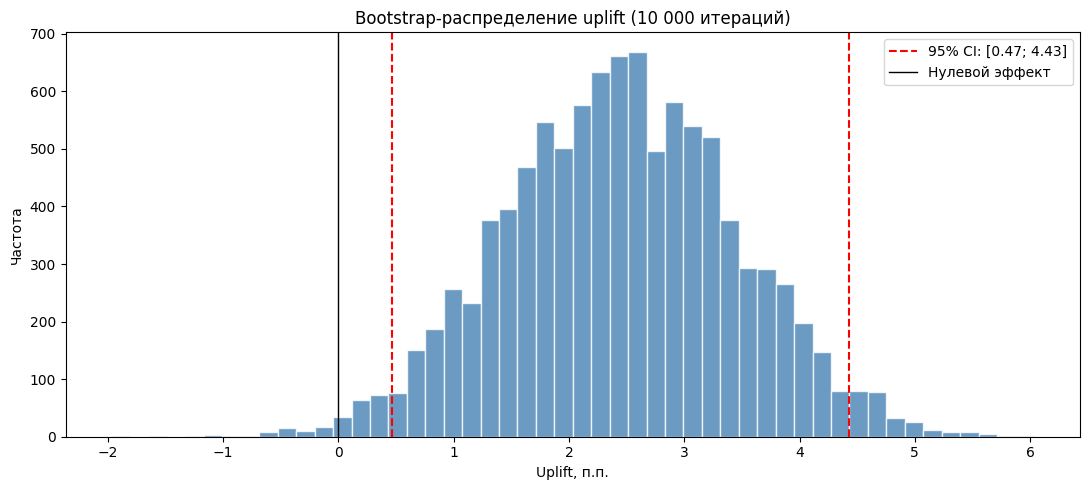

In [127]:
plt.figure(figsize=(11, 5))
plt.hist(boot_uplifts * 100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(ci_low_boot, color='red', linestyle='--', label=f'95% CI: [{ci_low_boot:.2f}; {ci_upp_boot:.2f}]')
plt.axvline(ci_upp_boot, color='red', linestyle='--')
plt.axvline(0, color='black', linewidth=1, label='Нулевой эффект')
plt.title('Bootstrap-распределение uplift (10 000 итераций)')
plt.xlabel('Uplift, п.п.')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

## Итоги Блока  

**Дизайн:** при baseline retention 17%, MDE 3 п.п., α=0.05 и мощности 0.8
требуется 2 632 клиента на группу. Сегмент At Risk (158K) покрывает
потребность с запасом.

**Анализ:** стратифицированная рандомизация обеспечила сопоставимость групп
(A/A-проверка пройдена). Заложенный uplift подтверждён двумя методами —
z-тестом (p < 0.05) и bootstrap (95% CI не содержит ноль).

**Ограничение:** эффект скидки симулирован, а не измерен. Реальный вывод
об окупаемости требует полноценного эксперимента с контролируемой рассылкой.